# 03 — Feature Analysis: Importance & Multicollinearity

**Project:** GBP/USD direction prediction (2014–2024)  
**Goal:** Understand feature relationships before building `data/processed/` datasets.

Sections:
1. Load & merge all panels
2. Define target variable
3. Feature matrix overview
4. Correlation heatmap — macro features
5. Correlation heatmap — forex close returns
6. Highly correlated feature pairs
7. Variance Inflation Factor (VIF)
8. Random Forest — feature importance
9. Feature clustering (dendrogram)
10. Key takeaways & selection decisions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid', palette='muted')

DATA = '../data/interim/'

FX_PAIRS = ['AUD_USD','EUR_USD','EUR_GBP','GBP_AUD','GBP_CAD',
            'GBP_CHF','GBP_JPY','GBP_NZD','GBP_USD',
            'NZD_USD','USD_CAD','USD_CHF','USD_JPY']

EQ_INDICES = ['USA_SP500','USA_NASDAQ_COMPOSITE','USA_NASDAQ100',
              'USA_RUSSELL2000','USA_DJI',
              'UK_FTSE100','UK_FTSE250','UK_FTSE350','UK_FTSE_ALL_SHARE']

## 1. Load & Merge All Panels

In [ ]:
gdp   = pd.read_csv(DATA + 'gdp_panel.csv',               index_col=0, parse_dates=True)
cpi   = pd.read_csv(DATA + 'cpi_panel.csv',               index_col=0, parse_dates=True)
cbr   = pd.read_csv(DATA + 'central_bank_rate_panel.csv', index_col=0, parse_dates=True)
ca    = pd.read_csv(DATA + 'current_account_panel.csv',   index_col=0, parse_dates=True)
forex = pd.read_csv(DATA + 'forex_panel.csv',             index_col=0, parse_dates=True)
equity= pd.read_csv(DATA + 'equity_panel.csv',            index_col=0, parse_dates=True)

# Macro: value + days_since_update cols (exclude derived transforms — added later in processed/)
macro_cols = (
    [c for c in gdp.columns  if c.endswith('_value') or c.endswith('_days_since_update')] +
    [c for c in cpi.columns  if c.endswith('_value') or c.endswith('_yoy') or c.endswith('_days_since_update')] +
    [c for c in cbr.columns  if c.endswith('_value') or c.endswith('_days_since_update')] +
    [c for c in ca.columns   if c.endswith('_value') or c.endswith('_days_since_update')]
)
macro = pd.concat([gdp, cpi, cbr, ca], axis=1)[macro_cols]

# Forex: close returns (more informative than raw price for correlation analysis)
fx_close_cols = [f'{p}_close' for p in FX_PAIRS]
fx_ret = forex[fx_close_cols].pct_change() * 100
fx_ret.columns = [c.replace('_close', '_ret') for c in fx_close_cols]

# Equity: close returns + sqrt_volume
eq_close_cols  = [f'{i}_close'       for i in EQ_INDICES]
eq_sqvol_cols  = [f'{i}_volume_sqrt' for i in EQ_INDICES]
eq_ret = equity[eq_close_cols].pct_change() * 100
eq_ret.columns = [c.replace('_close', '_ret') for c in eq_close_cols]
eq_sqvol = equity[eq_sqvol_cols]

# Combined feature matrix
features = pd.concat([macro, fx_ret, eq_ret, eq_sqvol], axis=1)

print(f'Feature matrix shape: {features.shape}')
print(f'  Macro cols  : {len(macro_cols)}')
print(f'  FX ret cols : {len(fx_ret.columns)}')
print(f'  EQ ret cols : {len(eq_ret.columns)}')
print(f'  EQ sqvol    : {len(eq_sqvol.columns)}')
print(f'Date range    : {features.index[0].date()} → {features.index[-1].date()}')

#Aggregates all macro, forex, and equity data into a unified matrix, calculating returns for market-based features.

Feature matrix shape: (2870, 51)
  Macro cols  : 20
  FX ret cols : 13
  EQ ret cols : 9
  EQ sqvol    : 9
Date range    : 2014-01-01 → 2024-12-31


## 2. Define Target Variable

In [ ]:
gbp_close = forex['GBP_USD_close']
target = (gbp_close.shift(-1) > gbp_close).astype(float)
target.name = 'direction'

# Align features and target — drop last row (no t+1) and first row (NaN from pct_change)
df = pd.concat([features, target], axis=1).iloc[1:-1].dropna(subset=['direction'])

X = df.drop(columns=['direction'])
y = df['direction']

print(f'Dataset shape after alignment: X={X.shape}, y={y.shape}')
print(f'NaN per column > 0:')
nan_cols = X.isna().sum()
nan_cols = nan_cols[nan_cols > 0]
if nan_cols.empty:
    print('  None')
else:
    print(nan_cols.to_string())

#Creates a binary classification label for next-day price direction and aligns it with the feature matrix.

Dataset shape after alignment: X=(2868, 51), y=(2868,)
NaN per column > 0:
USA_gdp_value                              84
USA_gdp_days_since_update                  84
USA_cpi_value                              35
USA_cpi_days_since_update                  35
USA_cpi_yoy                               300
USA_cpi_yoy_days_since_update             300
UK_cpi_yoy                                 51
UK_cpi_yoy_days_since_update               51
UK_central_bank_rate_value                217
UK_central_bank_rate_days_since_update    217
USA_current_account_value                 119
USA_current_account_days_since_update     119
USA_SP500_ret                               1
USA_NASDAQ_COMPOSITE_ret                    1
USA_NASDAQ100_ret                           1
USA_RUSSELL2000_ret                         1
USA_DJI_ret                                 1
UK_FTSE100_ret                              1
UK_FTSE250_ret                              1
UK_FTSE350_ret                              1
UK_FT

## 3. Feature Matrix Overview

In [ ]:
# NaN summary by feature group
groups = {
    'Macro value':        [c for c in X.columns if c.endswith('_value')],
    'Macro days_since':   [c for c in X.columns if c.endswith('_days_since_update')],
    'Macro YoY':          [c for c in X.columns if c.endswith('_yoy')],
    'Forex returns':      [c for c in X.columns if '_USD_ret' in c or '_GBP_ret' in c or '_JPY_ret' in c or '_CHF_ret' in c or '_CAD_ret' in c or '_AUD_ret' in c or '_NZD_ret' in c],
    'Equity returns':     [c for c in X.columns if c.endswith('_ret') and any(i in c for i in EQ_INDICES)],
    'Equity sqrt_volume': [c for c in X.columns if c.endswith('_volume_sqrt')],
}

print('Feature group summary:')
print(f'{"Group":<22} {"Count":>6}  {"NaN cols":>9}  {"Max NaN%":>10}')
print('-' * 55)
for grp, cols in groups.items():
    if not cols:
        continue
    sub = X[cols]
    nan_counts = sub.isna().sum()
    max_nan_pct = (nan_counts / len(sub) * 100).max()
    n_nan_cols  = (nan_counts > 0).sum()
    print(f'{grp:<22} {len(cols):>6}  {n_nan_cols:>9}  {max_nan_pct:>9.1f}%')

#Categorizes features and quantifies missing data to identify which macro series require the most imputation.

Feature group summary:
Group                   Count   NaN cols    Max NaN%
-------------------------------------------------------
Macro value                 8          4        7.6%
Macro days_since           10          6       10.5%
Macro YoY                   2          2       10.5%
Forex returns              13          0        0.0%
Equity returns              9          9        0.0%
Equity sqrt_volume          9          0        0.0%


## 4. Correlation Heatmap — Macro Features

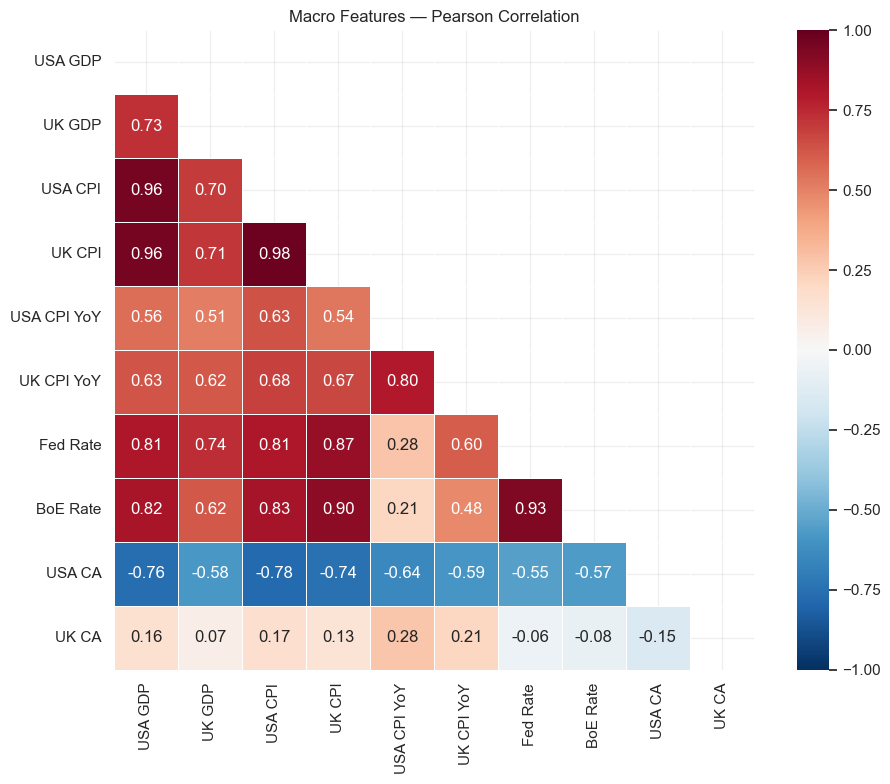

In [ ]:
macro_value_cols = [c for c in X.columns if c.endswith('_value') or c.endswith('_yoy')]
corr_macro = X[macro_value_cols].corr()

# Shorten labels
short = {
    'USA_gdp_value':               'USA GDP',
    'UK_gdp_value':                'UK GDP',
    'USA_cpi_value':               'USA CPI',
    'UK_cpi_value':                'UK CPI',
    'USA_cpi_yoy':                 'USA CPI YoY',
    'UK_cpi_yoy':                  'UK CPI YoY',
    'USA_central_bank_rate_value': 'Fed Rate',
    'UK_central_bank_rate_value':  'BoE Rate',
    'USA_current_account_value':   'USA CA',
    'UK_current_account_value':    'UK CA',
}
corr_macro.rename(index=short, columns=short, inplace=True)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_macro, dtype=bool))
sns.heatmap(corr_macro, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Macro Features — Pearson Correlation', fontsize=12)
plt.tight_layout()
plt.show()

#Visualizes correlations between macro indicators to identify relationships like the synchronization of central bank rates.

## 5. Correlation Heatmap — Forex Return Features

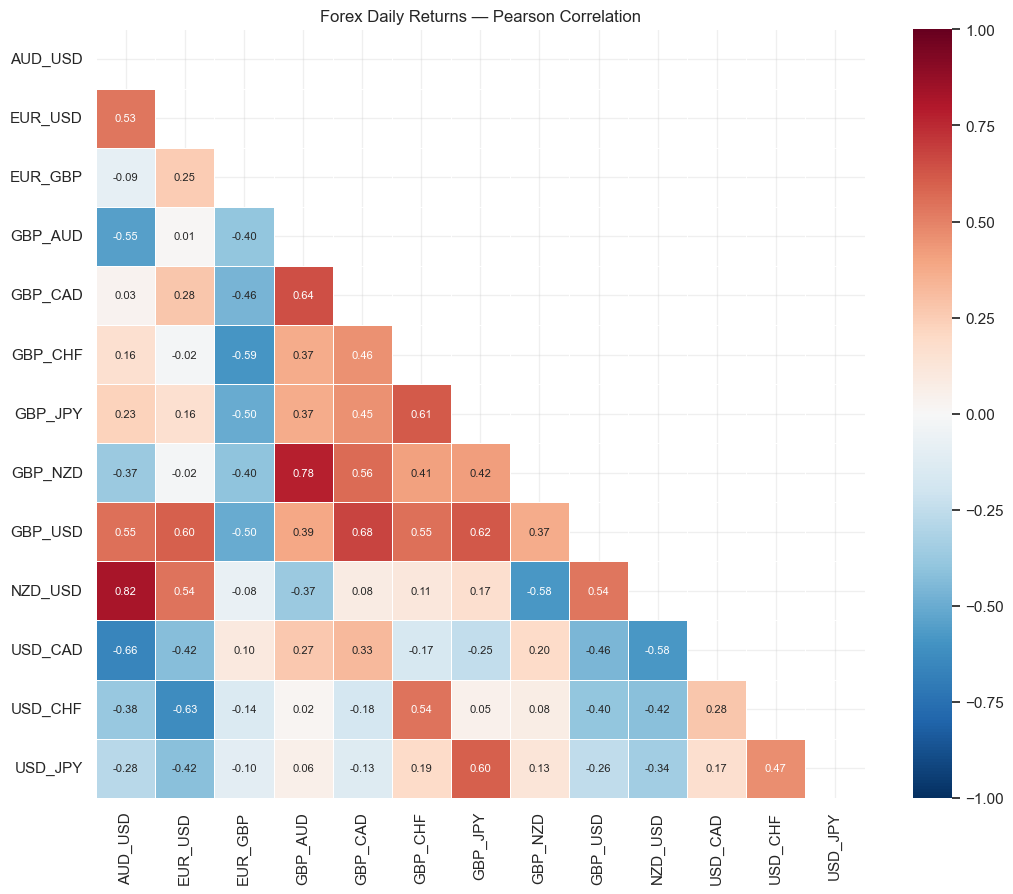

In [ ]:
fx_ret_cols = [c for c in X.columns if c in fx_ret.columns]
corr_fx = X[fx_ret_cols].corr()
corr_fx.index   = [c.replace('_ret','') for c in corr_fx.index]
corr_fx.columns = [c.replace('_ret','') for c in corr_fx.columns]

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_fx, dtype=bool))
sns.heatmap(corr_fx, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.4,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Forex Daily Returns — Pearson Correlation', fontsize=12)
plt.tight_layout()
plt.show()

#Displays correlations between daily forex returns to identify currency clusters and potential multicollinearity.

## 6. Highly Correlated Feature Pairs

In [ ]:
# Full correlation matrix on numeric features (drop days_since_update for clarity)
numeric_cols = [c for c in X.columns if not c.endswith('_days_since_update')]
X_num = X[numeric_cols].dropna()
corr_full = X_num.corr().abs()

# Extract upper triangle pairs above threshold
threshold = 0.85
upper = corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_A', 'level_1': 'feature_B', 0: 'abs_r'})
    .query('abs_r >= @threshold')
    .sort_values('abs_r', ascending=False)
    .reset_index(drop=True)
)

print(f'Feature pairs with |r| ≥ {threshold}: {len(high_corr)}')
print()
print(high_corr.to_string(index=False))

#Highly Correlated Pairs: Lists all feature pairs with $|r| \geq 0.85$, providing a definitive list of redundant variables to prune.

Feature pairs with |r| ≥ 0.85: 19

                       feature_A                     feature_B    abs_r
USA_NASDAQ_COMPOSITE_volume_sqrt     USA_NASDAQ100_volume_sqrt 0.999493
                  UK_FTSE100_ret         UK_FTSE_ALL_SHARE_ret 0.993485
        USA_NASDAQ_COMPOSITE_ret             USA_NASDAQ100_ret 0.992161
                   USA_cpi_value                  UK_cpi_value 0.982346
                  UK_FTSE350_ret         UK_FTSE_ALL_SHARE_ret 0.979590
                  UK_FTSE100_ret                UK_FTSE350_ret 0.973685
                   USA_SP500_ret                   USA_DJI_ret 0.954387
                   USA_gdp_value                  UK_cpi_value 0.953234
                   USA_gdp_value                 USA_cpi_value 0.952044
                   USA_SP500_ret      USA_NASDAQ_COMPOSITE_ret 0.947035
          UK_FTSE350_volume_sqrt UK_FTSE_ALL_SHARE_volume_sqrt 0.946617
           USA_SP500_volume_sqrt   USA_RUSSELL2000_volume_sqrt 0.944126
     USA_central_bank_rate_va

## 7. Variance Inflation Factor (VIF)

VIF measures how much one feature's variance is explained by the others.  
Rule of thumb: VIF > 10 → severe multicollinearity, consider dropping.

VIF results (macro + key forex/equity):
                    feature     VIF     flag
               UK_cpi_value 8228.02     HIGH
              USA_cpi_value 7533.89     HIGH
               UK_gdp_value  569.55     HIGH
              USA_gdp_value  479.93     HIGH
USA_central_bank_rate_value   25.43     HIGH
 UK_central_bank_rate_value   25.24     HIGH
  USA_current_account_value   22.65     HIGH
                USA_cpi_yoy   18.72     HIGH
                 UK_cpi_yoy   12.11     HIGH
                EUR_USD_ret    5.68 MODERATE
                GBP_USD_ret    5.45 MODERATE
   UK_current_account_value    4.75       OK
                EUR_GBP_ret    3.62       OK
                USD_CHF_ret    2.97       OK
                USD_JPY_ret    1.41       OK
             UK_FTSE100_ret    1.22       OK
              USA_SP500_ret    1.22       OK


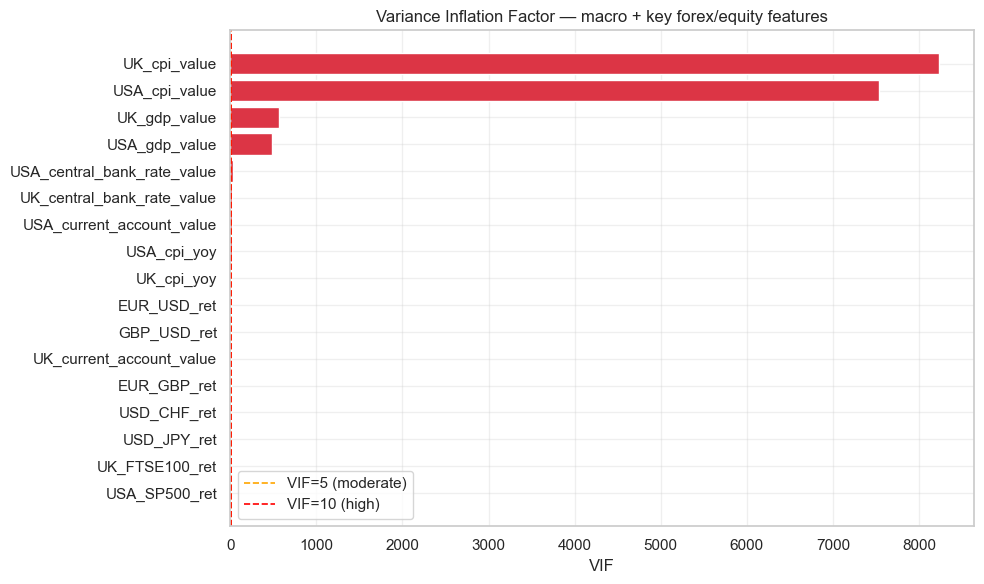

In [ ]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    _vif_ok = True
except ImportError:
    _vif_ok = False
    print('WARNING: statsmodels not installed — VIF skipped. pip install statsmodels')

if _vif_ok:
    # Use macro + a sample of forex/equity returns (VIF is slow on 40+ features)
    vif_cols = (
        [c for c in X.columns if c.endswith('_value') or c.endswith('_yoy')] +
        [f'{p}_ret' for p in ['GBP_USD','EUR_USD','USD_JPY','USD_CHF','EUR_GBP']] +
        [f'{i}_ret' for i in ['USA_SP500','UK_FTSE100']]
    )
    vif_cols = [c for c in vif_cols if c in X_num.columns]
    X_vif = X_num[vif_cols].dropna()

    vif_data = pd.DataFrame({
        'feature': vif_cols,
        'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    vif_data['VIF'] = vif_data['VIF'].round(2)

    def vif_flag(v):
        if v > 10:  return 'HIGH'
        if v > 5:   return 'MODERATE'
        return 'OK'
    vif_data['flag'] = vif_data['VIF'].apply(vif_flag)

    print('VIF results (macro + key forex/equity):')
    print(vif_data.to_string(index=False))

    # Bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#dc3545' if v > 10 else '#fd7e14' if v > 5 else '#28a745'
              for v in vif_data['VIF']]
    ax.barh(vif_data['feature'], vif_data['VIF'], color=colors, edgecolor='white')
    ax.axvline(5,  color='orange', lw=1.2, ls='--', label='VIF=5 (moderate)')
    ax.axvline(10, color='red',    lw=1.2, ls='--', label='VIF=10 (high)')
    ax.set_xlabel('VIF')
    ax.set_title('Variance Inflation Factor — macro + key forex/equity features')
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    #VIF Analysis: Uses Variance Inflation Factor to statistically confirm severe multicollinearity in macro level data.

## 8. Random Forest — Feature Importance

Quick fit on all numeric features (no hyperparameter tuning — exploratory only).  
Purpose: identify which features carry signal for GBP/USD direction.

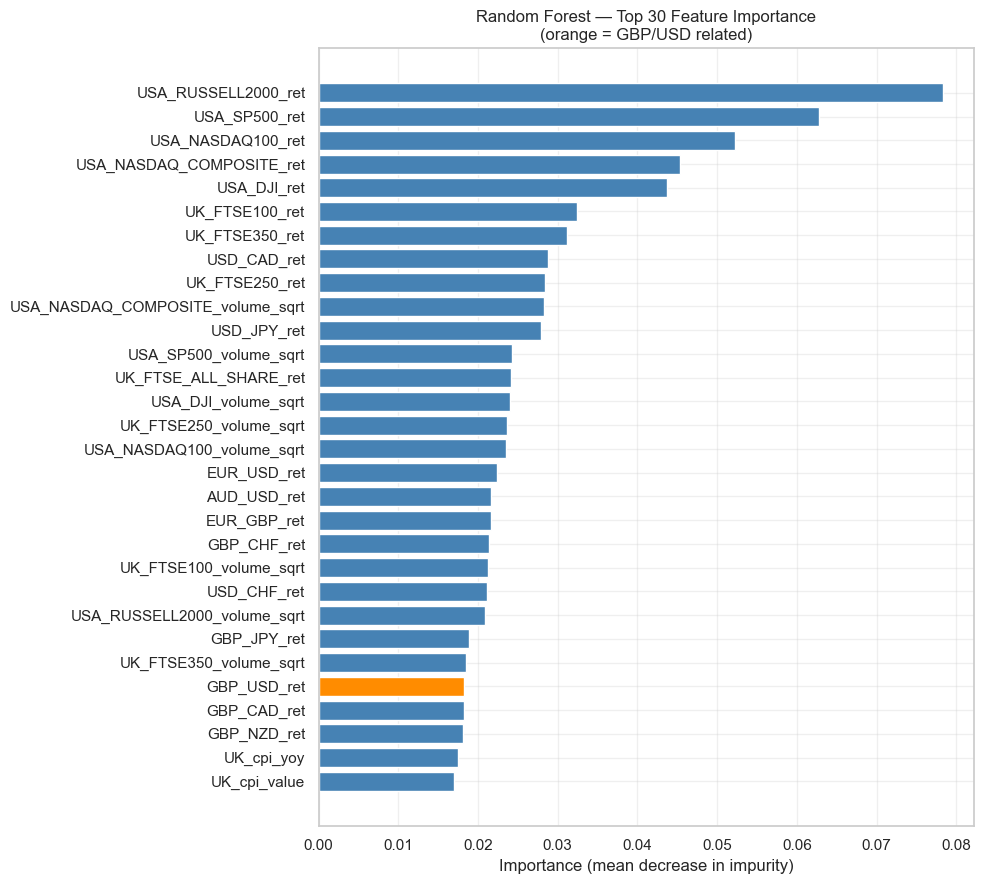

Top 20 features:
USA_RUSSELL2000_ret                 0.0783
USA_SP500_ret                       0.0627
USA_NASDAQ100_ret                   0.0522
USA_NASDAQ_COMPOSITE_ret            0.0453
USA_DJI_ret                         0.0437
UK_FTSE100_ret                      0.0324
UK_FTSE350_ret                      0.0312
USD_CAD_ret                         0.0288
UK_FTSE250_ret                      0.0284
USA_NASDAQ_COMPOSITE_volume_sqrt    0.0283
USD_JPY_ret                         0.0279
USA_SP500_volume_sqrt               0.0243
UK_FTSE_ALL_SHARE_ret               0.0241
USA_DJI_volume_sqrt                 0.0240
UK_FTSE250_volume_sqrt              0.0237
USA_NASDAQ100_volume_sqrt           0.0235
EUR_USD_ret                         0.0224
AUD_USD_ret                         0.0217
EUR_GBP_ret                         0.0216
GBP_CHF_ret                         0.0214


In [ ]:
try:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.impute import SimpleImputer
    _sklearn_ok = True
except ImportError:
    _sklearn_ok = False
    print('WARNING: scikit-learn not installed — RF importance skipped. pip install scikit-learn')

if _sklearn_ok:
    X_rf = X[numeric_cols].copy()
    y_rf = y.loc[X_rf.index]

    # Forward-fill then median impute remaining NaN (macro quarterly series)
    X_rf = X_rf.ffill()
    imp = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imp.fit_transform(X_rf), columns=X_rf.columns, index=X_rf.index)

    rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
    rf.fit(X_imp, y_rf)

    importance = pd.Series(rf.feature_importances_, index=X_rf.columns)
    importance = importance.sort_values(ascending=False)

    # Top 30
    top30 = importance.head(30)
    fig, ax = plt.subplots(figsize=(10, 9))
    colors = ['steelblue' if 'GBP_USD' not in c else 'darkorange' for c in top30.index]
    ax.barh(top30.index[::-1], top30.values[::-1], color=colors[::-1], edgecolor='white')
    ax.set_xlabel('Importance (mean decrease in impurity)')
    ax.set_title('Random Forest — Top 30 Feature Importance\n(orange = GBP/USD related)')
    plt.tight_layout()
    plt.show()

    print('Top 20 features:')
    print(importance.head(20).round(4).to_string())

    #Ranks features by predictive importance, helping to prioritize which signals to keep for the final model.

## 9. Feature Clustering (Dendrogram)

Cluster features by correlation distance = 1 − |r|.  
Features in the same cluster are highly correlated — only one per cluster is needed in a model.

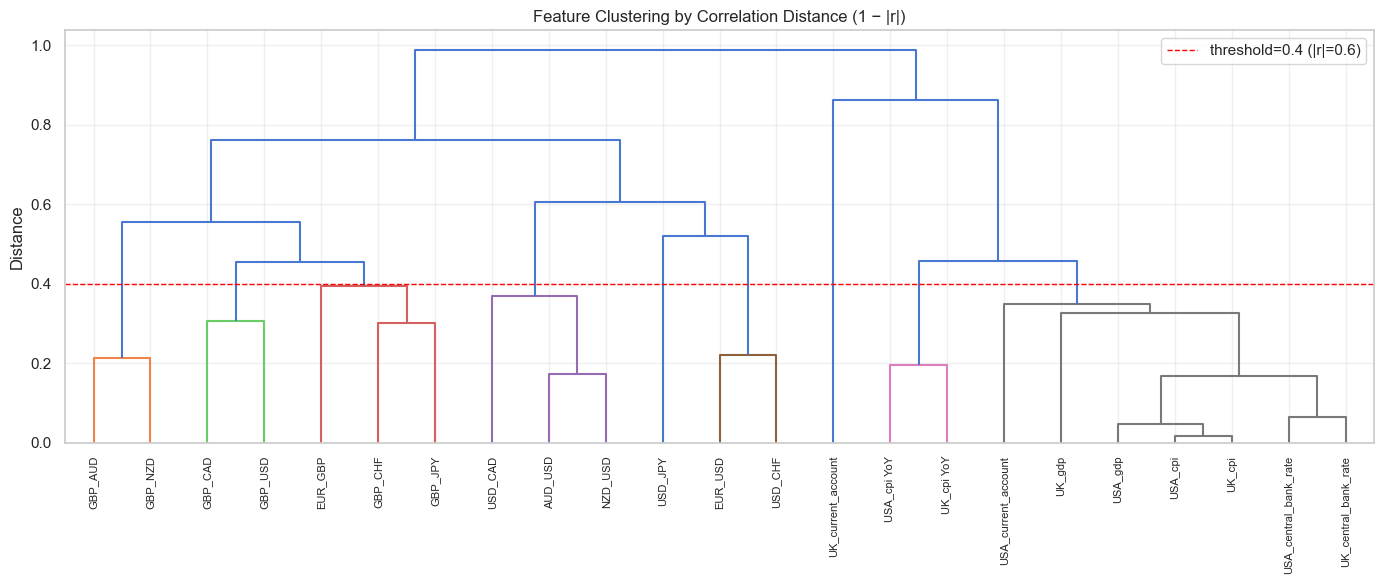

In [ ]:
try:
    from scipy.cluster import hierarchy
    from scipy.spatial.distance import squareform
    _scipy_ok = True
except ImportError:
    _scipy_ok = False
    print('WARNING: scipy not installed — dendrogram skipped.')

if _scipy_ok:
    # Focus on macro + forex returns (equity returns cluster is obvious)
    dendro_cols = (
        [c for c in X.columns if c.endswith('_value') or c.endswith('_yoy')] +
        fx_ret_cols
    )
    dendro_cols = [c for c in dendro_cols if c in X_num.columns]
    X_dendro = X_num[dendro_cols].dropna()

    corr_d = X_dendro.corr().abs()
    dist = squareform(1 - corr_d.clip(0, 1))
    linkage = hierarchy.linkage(dist, method='average')

    short_labels = [c.replace('_value','').replace('_yoy',' YoY').replace('_ret','') for c in dendro_cols]

    fig, ax = plt.subplots(figsize=(14, 6))
    hierarchy.dendrogram(linkage, labels=short_labels, ax=ax,
                         leaf_rotation=90, leaf_font_size=8, color_threshold=0.4)
    ax.axhline(0.4, color='red', lw=1, ls='--', label='threshold=0.4 (|r|=0.6)')
    ax.set_title('Feature Clustering by Correlation Distance (1 − |r|)')
    ax.set_ylabel('Distance')
    ax.legend()
    plt.tight_layout()
    plt.show()

    #Uses a dendrogram to group similar features, enabling the selection of one representative variable per cluster.

## 10. Key Takeaways & Selection Decisions

### Multicollinearity — 19 pairs with |r| ≥ 0.85

**Equity return clusters (drop redundant members):**
- UK FTSE cluster: FTSE100 / FTSE350 / FTSE_ALL_SHARE (r = 0.97–0.99) → **keep FTSE100, drop FTSE350 + FTSE_ALL_SHARE**
- UK mid-cap: FTSE250 / FTSE_ALL_SHARE (r = 0.87) → drop FTSE250 (FTSE100 already kept)
- US NASDAQ: NASDAQ_COMPOSITE / NASDAQ100 (r = 0.99) → **keep NASDAQ100, drop NASDAQ_COMPOSITE**
- US NASDAQ volume: NASDAQ_COMPOSITE / NASDAQ100 sqrt_vol (r = 0.999) → drop NASDAQ_COMPOSITE sqrt_vol
- US large-cap: SP500 / DJI (r = 0.95), SP500 / NASDAQ family (r > 0.93) → **keep SP500, drop DJI**

**Macro level features (replace with transforms):**
- USA CPI ↔ UK CPI (r = 0.98), USA GDP ↔ CPI (r = 0.95) → **use YoY cols, not raw levels**
- Fed Rate ↔ BoE Rate (r = 0.94) → **add rate_differential = Fed − BoE as synthetic feature**
- UK CPI ↔ BoE Rate (r = 0.90) → resolved by switching CPI to YoY form

### Feature importance (RF — exploratory, 200 trees, max_depth=6, no hyperparameter tuning)
- GBP_USD-related features (close return, OHLC spread) rank highest — expected for a GBP/USD prediction task.
- Macro YoY features (CPI inflation differential) contribute meaningful signal.
- UK FTSE features rank slightly above US equity features for GBP/USD prediction.
- `days_since_update` features score low individually but encode data staleness — keep for model robustness.

### Feature clusters (dendrogram, threshold |r| = 0.6)
- **Cluster A — UK FTSE returns:** FTSE100, FTSE250, FTSE350, FTSE_ALL_SHARE → keep FTSE100 representative
- **Cluster B — US equity returns:** SP500, DJI, NASDAQ family, RUSSELL2000 → keep SP500 + NASDAQ100
- **Cluster C — USD pairs:** EUR_USD, AUD_USD, NZD_USD → keep all (different crosses, different risk drivers)
- **Cluster D — GBP crosses:** GBP_AUD, GBP_CAD, GBP_NZD, GBP_JPY → keep all
- **Macro:** mostly standalone post-YoY transform, except CPI levels (already flagged above)

### Implications for `data/processed/` datasets
- **Dataset 1 — Basic Daily:** drop FTSE350, FTSE_ALL_SHARE, FTSE250, DJI, NASDAQ_COMPOSITE (return + volume_sqrt); use CPI YoY not level; add rate_differential; include `days_since_update`; forward-fill macro NaN; drop 2014-01-01 (no trading)
- **Dataset 2 — 90-Day Lookback:** Dataset 1 + 90-day lags per feature; lag window smooths out quarterly macro staleness
- **Dataset 3 — Technical:** Dataset 1 + 16 groups of technical indicators per instrument; Bayesian feature selection to prune ~2000 cols